# Repaso final: Turismo internacional

Este repaso usa un contexto distinto al examen, pero practica los mismos patrones: recorrer datos, crear una función, filtrar, agrupar, ordenar, graficar e interpretar.

Trabaje con `turismo_internacional_repaso.csv` sin modificarlo. **Antes de iniciar, guarde una copia como `Apellido_Nombre_Repaso_Final.ipynb`.**

Distribución inequívoca: Parte 1, Parte 2, Parte 3, Parte 4, Parte 5 y cierre.


## Parte 1 — Preparación

**TODO 1.1 — Entrada, proceso y salida**

Escriba aquí una frase que identifique: (1) la entrada —el archivo y sus datos—, (2) el proceso —las operaciones de análisis— y (3) la salida —tablas, gráficos e interpretaciones.


In [17]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import pandas as pd
import matplotlib.pyplot as plt

archivo = 'turismo_internacional_repaso.csv'
df = pd.read_csv(archivo)

print()
print("--TIPO DATOS--")
print(df.info())
print("\n--NULOS--")
print(df.isna().sum())

filtro = df.isna().any(axis=1)
display(df[filtro])

df_limpio = df.dropna().copy()
df.dropna(inplace=True)

df.head()



--TIPO DATOS--
<class 'pandas.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   pais            130 non-null    str    
 1   anio            130 non-null    int64  
 2   llegadas_miles  117 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 3.2 KB
None

--NULOS--
pais               0
anio               0
llegadas_miles    13
dtype: int64


,pais,anio,llegadas_miles
52,Guatemala,2012,NaN
53,Guatemala,2013,NaN
54,Guatemala,2014,NaN
55,Guatemala,2015,NaN
56,Guatemala,2016,NaN
57,Guatemala,2017,NaN
58,Guatemala,2018,NaN
59,Guatemala,2019,NaN
60,Guatemala,2020,NaN
61,Guatemala,2021,NaN


,pais,anio,llegadas_miles
0,Belice,2012,294.495
1,Belice,2013,294.209
2,Belice,2014,320.564
3,Belice,2015,341.125
4,Belice,2016,386.698


**TODO 1.2 — Construir la cantidad de visitantes**

A partir de `llegadas_miles`, cree la columna `visitantes` en personas. Redondee el resultado y use el tipo entero anulable `Int64`, para conservar como dato faltante los años que no tengan una cifra publicada.


In [19]:
# TODO: cree df["visitantes"] desde df["llegadas_miles"].
# Debe multiplicar por 1 000, redondear y convertir a enteros anulables (Int64).
# No reemplace los valores faltantes por cero.

df['visitantes'] = (df['llegadas_miles'] * 1000).round().astype("Int64")
display(df)

,pais,anio,llegadas_miles,visitantes
0,Belice,2012,294.495,294495
1,Belice,2013,294.209,294209
2,Belice,2014,320.564,320564
3,Belice,2015,341.125,341125
4,Belice,2016,386.698,386698
...,...,...,...,...
125,Perú,2020,897.905,897905
126,Perú,2021,444.331,444331
127,Perú,2022,2009.275,2009275
128,Perú,2023,2524.658,2524658


**TODO 1.3 — Exploración, nulos y limpieza**

Antes de analizar, explore la estructura del DataFrame y la calidad de los datos.

1. Muestre `shape`, `dtypes`, `info()` y la cantidad de nulos por columna.
2. Identifique las filas con `llegadas_miles` faltante y explique qué representan según la documentación de fuentes.
3. Cree `df_limpio` sin valores faltantes en `llegadas_miles`. No convierta los nulos en cero y conserve `df` sin modificar para poder comparar ambos conjuntos.


In [20]:
# TODO: explore df con shape, dtypes, info() e isna().sum().
print("Dimesiones:", df.shape)
# TODO: muestre las filas con llegadas_miles faltante y explique su significado.
print('Tipo datos:\n', df.dtypes)
display(df.info())
# TODO: cree df_limpio excluyendo únicamente los nulos de llegadas_miles.
# No reemplace valores faltantes por cero.
filas_nulas = df[df['llegadas_miles'].isna()]
display(filas_nulas)
df = df.dropna() # es lo mismo que df.dropna(inplace=True)

df.head()

Dimesiones: (117, 4)
Tipo datos:
 pais                  str
anio                int64
llegadas_miles    float64
visitantes          Int64
dtype: object
<class 'pandas.DataFrame'>
Index: 117 entries, 0 to 129
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   pais            117 non-null    str    
 1   anio            117 non-null    int64  
 2   llegadas_miles  117 non-null    float64
 3   visitantes      117 non-null    Int64  
dtypes: Int64(1), float64(1), int64(1), str(1)
memory usage: 4.7 KB


None

,pais,anio,llegadas_miles,visitantes


,pais,anio,llegadas_miles,visitantes
0,Belice,2012,294.495,294495
1,Belice,2013,294.209,294209
2,Belice,2014,320.564,320564
3,Belice,2015,341.125,341125
4,Belice,2016,386.698,386698


## Parte 2 — Python base: registros y función

1. Muestre `shape`, `dtypes` y una descripción breve de cada columna.
2. Convierta el DataFrame en una lista de diccionarios llamada `registros`.
3. Con un ciclo y una condición, cuente los registros cuya cantidad de llegadas es mayor a 3 000 miles.
4. Complete `resumen_pais`. Debe devolver un diccionario con país, cantidad de años, total y promedio de llegadas para el país solicitado. Si no existe, debe devolver `None`.


In [21]:
# Escriba su solución aquí.
registros = df.to_dict(orient='records')
print(registros[:5])
contador = 0 # Almacenar las cantidad de regsitros superiores a 3000
for registro in registros:
    if registro['llegadas_miles'] >= 3000:
        contador += 1
print("Registros con mas de 3 000 llegadas:", contador)


def resumen_pais(registros, pais):
    # Recorra los registros y acumule solo los del país indicado.
    pass

# Pruebe la función con 'Costa Rica' y con un país inexistente.
print(resumen_pais(registros,'Costa Rica'))
print(resumen_pais(registros, 'País no existe'))


[{'pais': 'Belice', 'anio': 2012, 'llegadas_miles': 294.495, 'visitantes': 294495}, {'pais': 'Belice', 'anio': 2013, 'llegadas_miles': 294.209, 'visitantes': 294209}, {'pais': 'Belice', 'anio': 2014, 'llegadas_miles': 320.564, 'visitantes': 320564}, {'pais': 'Belice', 'anio': 2015, 'llegadas_miles': 341.125, 'visitantes': 341125}, {'pais': 'Belice', 'anio': 2016, 'llegadas_miles': 386.698, 'visitantes': 386698}]
Registros con mas de 3 000 llegadas: 30
None
None


## Parte 3 — Pandas: Análisis Comparativo y de Impacto

Con el nuevo conjunto de datos, podemos realizar un análisis regional más profundo.

1.  **Ranking de Líderes Regionales:**
    *   Calcula el **total de llegadas por país** para todo el período (2012-2024).
    *   Genera un ranking ordenado de mayor a menor para identificar los 3 países con más llegadas en la región.

2.  **Análisis de Impacto (COVID-19):**
    *   Crea un nuevo DataFrame que contenga únicamente los datos de 2019 y 2020.
    *   A partir de él, calcula la **caída porcentual** en el turismo para cada país. La fórmula es `((llegadas_2019 - llegadas_2020) / llegadas_2019) * 100`.
    *   Muestra una tabla con los resultados, ordenada de mayor a menor caída porcentual, para ver qué países fueron los más afectados.


In [22]:
# Escriba sus filtros, cálculos, tabla resumen y ranking aquí.
top_3 = df.groupby('pais')['visitantes'].sum().sort_values(ascending=False)
print("Ranking de Visitantes por País Top 3")
display(top_3.head(3))
# Para el ranking, agrupe las llegadas_miles por país, ordene de mayor a menor
# y conserve los tres primeros resultados.


Ranking de Visitantes por País Top 3


pais
México      451162715
Colombia     39727076
Perú         38380784
Name: visitantes, dtype: Int64

In [28]:
df_2019 = df[df['anio'] == 2019].set_index('pais')['llegadas_miles']
df_2020 = df[df['anio'] == 2020].set_index('pais')['llegadas_miles']
#display(df_2019)
#display(df_2020)
df_analisis = pd.DataFrame({'llegadas_2019':df_2019,'llegadas_2020':df_2020}).dropna()

df_analisis['caida_porcentual'] = ((df_analisis['llegadas_2019'] - df_analisis['llegadas_2020']) / df_analisis['llegadas_2019']) * 100

display(
        df_analisis
        .sort_values('caida_porcentual', ascending=False)
        .style.format({
            'llegadas_2019': '{:,.0f}',
            'llegadas_2020': '{:,.0f}',
            'caida_porcentual': '{:.2f}%'
        })
    )



,llegadas_2019,llegadas_2020,caida_porcentual
pais,,,
Perú,"4,372",898,79.46%
Belice,503,114,77.27%
El Salvador,"2,639",707,73.21%
Honduras,"1,120",333,70.27%
Panamá,"1,771",539,69.57%
Costa Rica,"3,139","1,011",67.79%
Nicaragua,"1,455",474,67.42%
Colombia,"3,215","1,120",65.16%
México,"45,024","24,285",46.06%


## Parte 4 — Visualización Comparativa e Interpretación

Ahora, vamos a contar la historia de los datos con visualizaciones más ricas.

1.  **Gráfico de Líneas Comparativo:**
    *   Construye una gráfica de líneas que compare la evolución de llegadas para **todos los países** a lo largo de los años.
    *   **Interpretación:** Tu análisis debe mencionar: (1) La escala de México en comparación con los demás, (2) la tendencia general antes de 2020, y (3) el impacto visible de la pandemia en 2020 en todo el grupo.

2.  **Gráfico de Barras del Impacto (COVID-19):**
    *   Crea un **gráfico de barras horizontales** que muestre la **caída porcentual** por país que calculaste en la Parte 3.
    *   **Interpretación:** Explica qué países sufrieron el mayor y menor impacto relativo según la gráfica.

3.  **Gráfico de Barras de Recuperación:**
    *   Crea un **gráfico de barras agrupadas** que compare las llegadas de **2019 (pre-pandemia)** con las de **2022 (recuperación)** para cada país.
    *   **Interpretación:** Describe qué países parecen haberse recuperado más rápido y si alguno ha superado sus niveles pre-pandemia.


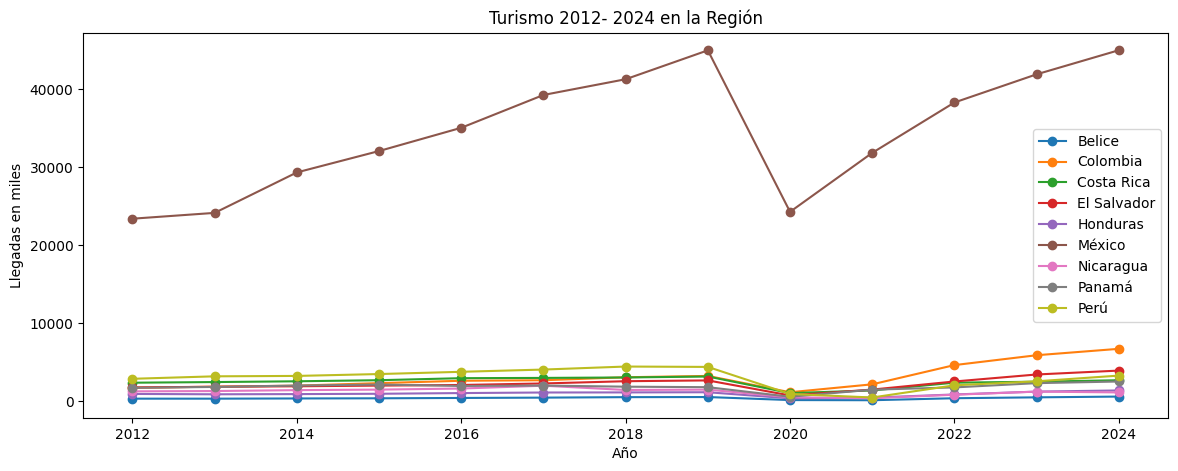

In [35]:
# Escriba aquí las tres gráficas.
# Use plt.show() al finalizar cada una e incluya una interpretación escrita.
plt.figure(figsize=(14,5))
for pais, datos in df.groupby('pais'):
    plt.plot(datos['anio'],datos['llegadas_miles'], marker= 'o', label=pais)
    
plt.title("Turismo 2012- 2024 en la Región")
plt.xlabel("Año")
plt.ylabel('Llegadas en miles')
plt.legend()

minimo = df['llegadas_miles'].min() - 100
maximo = 8000
#plt.ylim(minimo, maximo)
plt.show()

<Axes: ylabel='pais'>

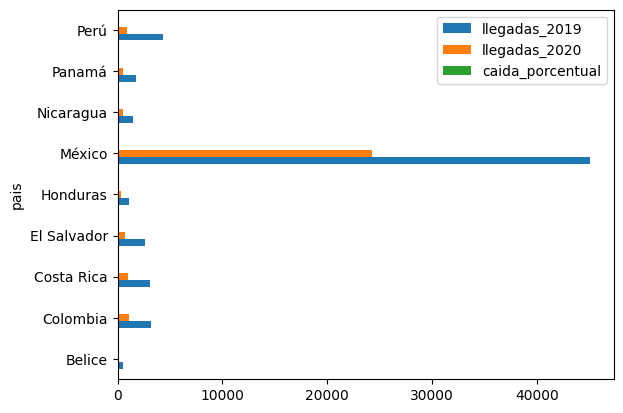

In [ ]:
df_analisis.plot(kind='barh')

plt.figure(figsize=(10, 4))
plt.barh(df_analisis.index, df_analisis['caida_porcentual'])
plt.show()

## Parte 5 — Mini-simulacro individual

Sin consultar soluciones, resuelva lo siguiente:

1. Defina la lista de países de Centroamérica: Belice, Costa Rica, El Salvador, Guatemala, Honduras, Nicaragua y Panamá. Convierta el DataFrame a una lista de diccionarios y cree una función que recorra los registros, use una condición y devuelva el total de llegadas de un país indicado; devuelva `None` si no existe.
2. Use un filtro compuesto con `isin(...)` para conservar únicamente Centroamérica y registros de 2019 o posteriores. Excluya los valores faltantes antes del análisis y guarde el resultado como `df_centroamerica`.
3. Con `df_centroamerica`, cree un resumen con `groupby(...).agg(...)` y seleccione con `nlargest(5, 'visitantes')` las cinco observaciones de mayor valor.
4. Elabore una gráfica de barras horizontales del ranking regional en visitantes y redacte un hallazgo numérico verificable, una interpretación y una limitación del análisis de Centroamérica.

**Autoevaluación:** ¿su respuesta incluye lista de diccionarios, ciclo, condición y función?, ¿sus filtros usan la columna correcta?, ¿aplicó `groupby(...).agg(...)` y `nlargest(5, ...)`?, ¿sus gráficos son legibles?, ¿sus afirmaciones tienen evidencia y una limitación?


In [ ]:
# Resuelva aquí el mini-simulacro.
# Defina la lista regional y cree df_centroamerica con el filtro compuesto y sin valores faltantes.
# Incluya la función, groupby(...).agg(...), nlargest(5, 'visitantes')
# y su interpretación de Centroamérica en visitantes, con evidencia y limitación.


## Cierre y autoevaluación

Compare su trabajo con la lista de autoevaluación de la Parte 5. Entregue el notebook con su nombre, código ejecutado, tres gráficos, interpretaciones con evidencia y una limitación. La retroalimentación docente se realiza después del intento individual.
